<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/3x3hj8VY/pngtree-colorful-pastel-gradient-background-texture-in-shades-of-pink-purple-blue-image-16381316.jpg);font-family:newtimeroman;font-size:120%;color:black;text-align:center;border-radius:15px 50px; padding:7px">I. PREPROCESSING</p>

<a class="btn" href="#home">📅 Data preprocessing</a>

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
df = pd.read_csv("data/dataset_financier.csv")
df.head()

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,agence,banque,lieu
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,Agence_Centre,Société Générale,Bafoussam
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,Agence_Centre,UBA,Douala
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,77179.593209,Agence_Sud,UBA,Bafoussam
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,Agence_Centre,UBA,Douala
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,Agence_Centre,Ecobank,Bafoussam


In [76]:
# retirer la colonne depenses pour l'application streamlit
data = df.drop(['depenses'], axis=1)
data

,bilan_financier,actifs,revenu,taux_interet,flux_tresorerie,capital,agence,banque,lieu
0,57450.712295,29795.488056,2459.857380,4.850180,9549.649146,36581.956747,Agence_Centre,Société Générale,Bafoussam
1,47926.035482,26472.435780,2884.385063,0.854030,6207.981496,38725.670920,Agence_Centre,UBA,Douala
2,59715.328072,20417.412589,2366.064063,9.724614,11458.554375,77179.593209,Agence_Sud,UBA,Bafoussam
3,72845.447846,15471.442556,2753.630776,5.180104,4151.884734,36901.898344,Agence_Centre,UBA,Douala
4,46487.699379,24887.563195,1485.108266,6.141862,3848.927628,46121.492335,Agence_Centre,Ecobank,Bafoussam
...,...,...,...,...,...,...,...,...,...
995,45783.495607,27491.051668,3061.984415,3.340455,10283.863134,48249.121062,Agence_Centre,BGFI,Bafoussam
996,76965.297903,19814.351185,3206.202032,1.068210,5123.367899,38937.469425,Agence_Sud,Ecobank,Garoua
997,59612.642919,13826.877441,2006.591540,2.388452,2480.285288,34553.303006,Agence_Nord,Société Générale,Yaoundé
998,41432.315153,18858.531252,3267.341134,9.492812,10892.386159,50680.692790,Agence_Sud,UBA,Yaoundé


In [78]:
# enregistrer data pour l'application streamlit
data.to_csv("dataset_financier_testing.csv",index=None)

In [45]:
# description du dataset
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
bilan_financier,1000.0,50289.980837,14688.239073,1380.989899,40286.145418,50379.509184,59719.158132,107790.972360
actifs,1000.0,20495.853661,6982.180641,-582.720443,15756.308177,20441.539926,25102.175239,42351.752975
revenu,1000.0,3004.667372,786.763425,584.390275,2481.600309,2999.799388,3528.732251,6140.990165
depenses,1000.0,1490.640391,513.566263,35.275655,1131.289773,1500.092287,1833.472705,3121.546485
taux_interet,1000.0,4.991526,2.901605,0.061838,2.457276,4.914739,7.538136,9.993503
flux_tresorerie,1000.0,9910.662587,2963.913307,1500.909130,7978.062358,9885.273463,11879.381786,19338.730603
capital,1000.0,39582.085591,12364.166625,5205.833442,30915.352716,39480.431990,48259.573668,77179.593209


In [46]:
# compréhension typage du dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bilan_financier  1000 non-null   float64
 1   actifs           1000 non-null   float64
 2   revenu           1000 non-null   float64
 3   depenses         1000 non-null   float64
 4   taux_interet     1000 non-null   float64
 5   flux_tresorerie  1000 non-null   float64
 6   capital          1000 non-null   float64
 7   agence           1000 non-null   object 
 8   banque           1000 non-null   object 
 9   lieu             1000 non-null   object 
dtypes: float64(7), object(3)
memory usage: 78.2+ KB


In [47]:
# trois colonnes catégorielles qui doivent etre encodés et le reste des colonnes ont des types logiques

In [48]:
# valeurs manquantes
df.isna().sum()
# pas de valeur manquantes, pas de colonnes inutiles, pas de colonnes déséquilibrées

bilan_financier    0
actifs             0
revenu             0
depenses           0
taux_interet       0
flux_tresorerie    0
capital            0
agence             0
banque             0
lieu               0
dtype: int64

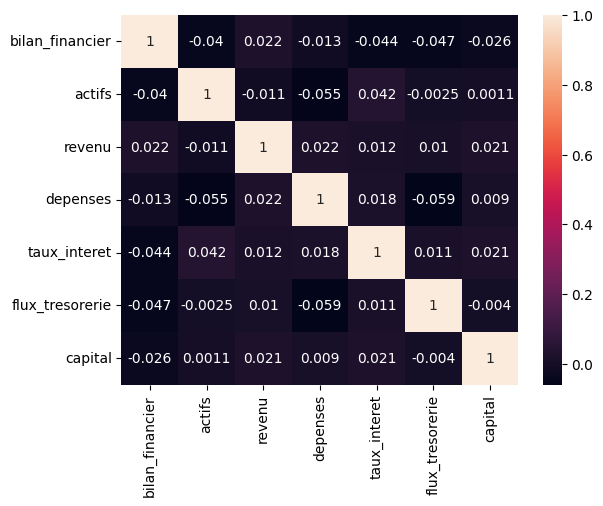

In [49]:
# corrélation entre les colonnes
data_numericals = df.drop(['agence','banque','lieu'], axis=1)
sns.heatmap(data_numericals.corr(), annot=True)
plt.show()

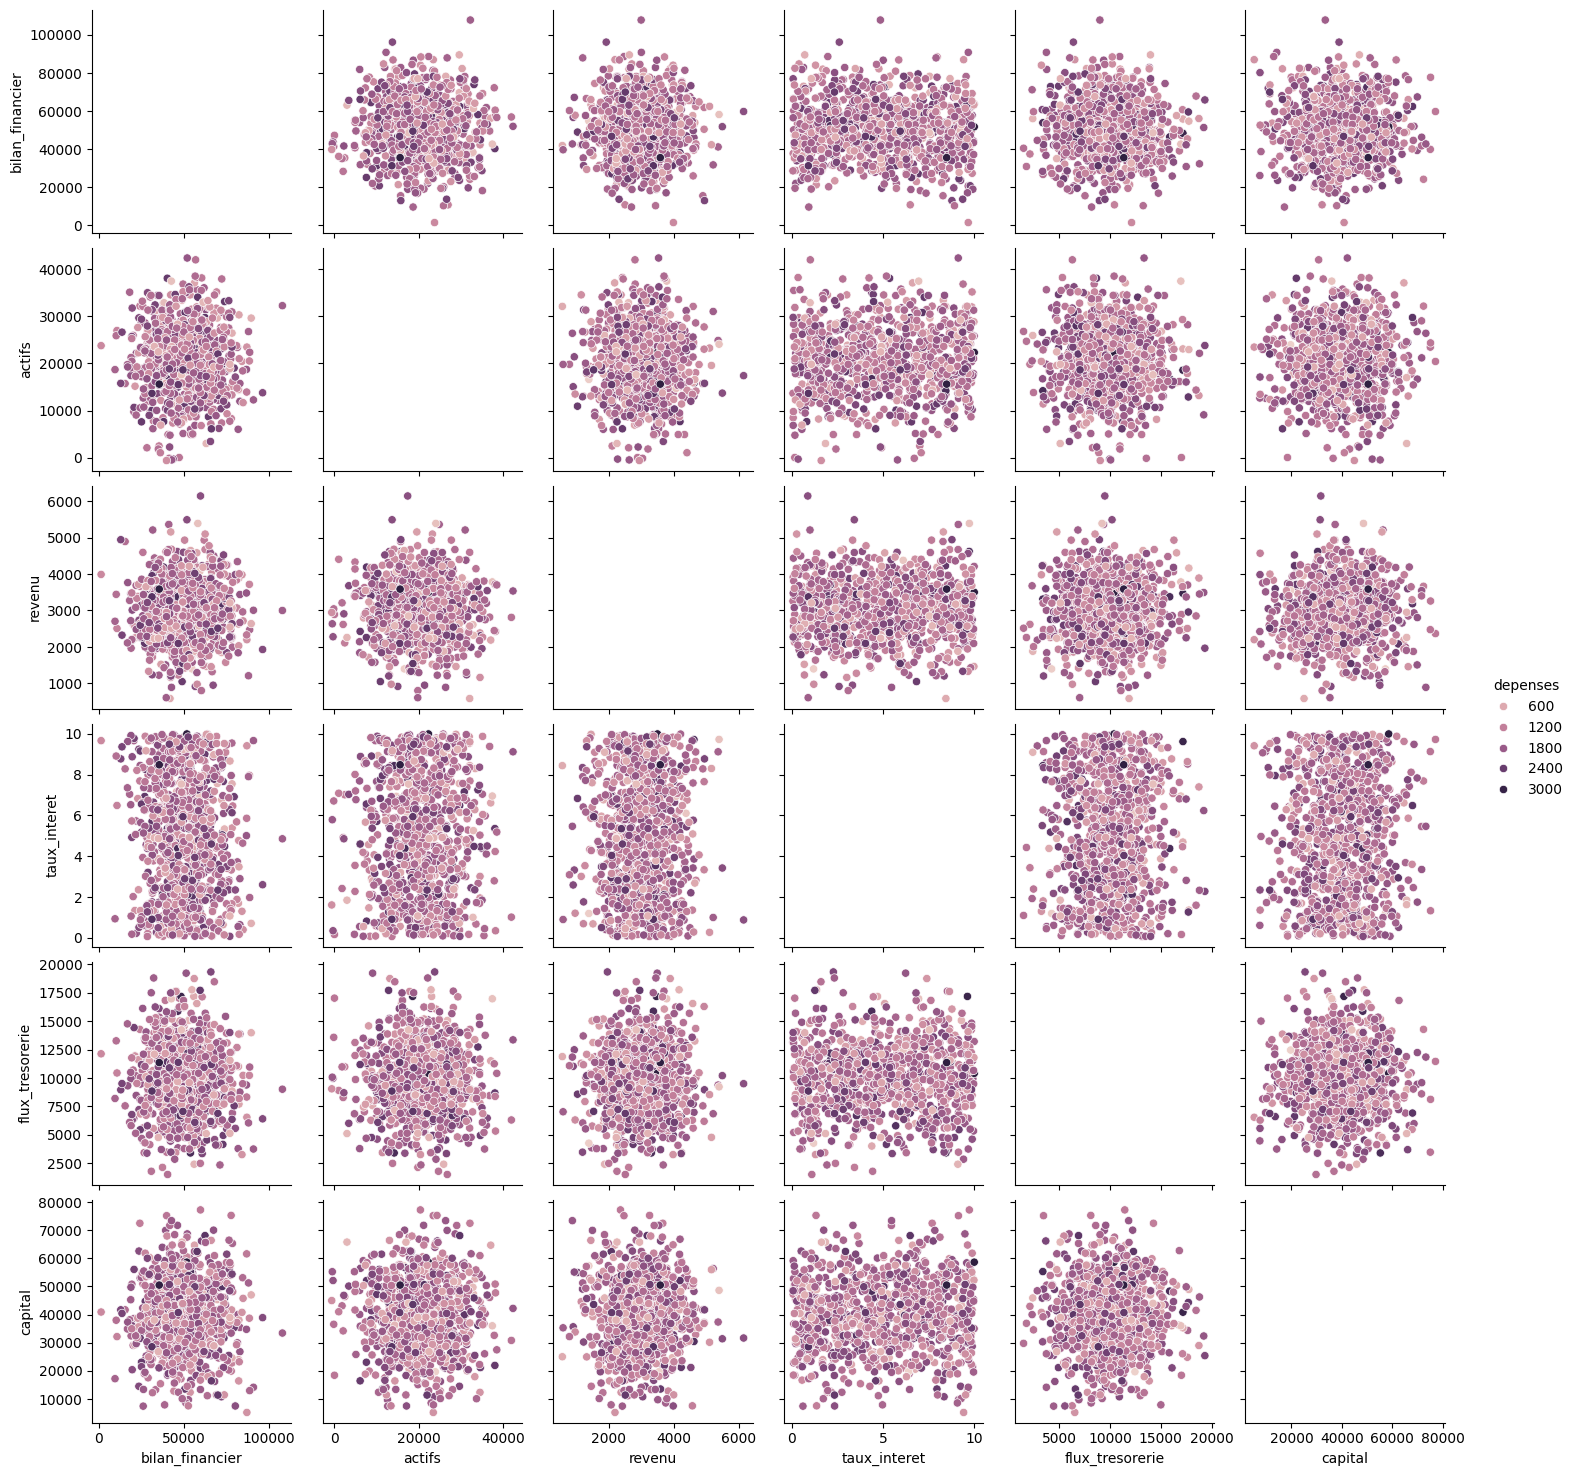

In [50]:
# pas de corrélation fortes entre les colonnes, aucune n'est lié ou dépendante de l'autre
# essayons de faire un pairplot pour observer: les valeurs abérantes s'il y'en a, les relations entre toutes les paires de variables numériques
sns.pairplot(data_numericals, hue="depenses")

In [51]:
# les données sont plus ou moins regroupées, il n'ya pas de point isolées du moins pas assez, 
# donc nous pouvons dire que notre dataset est propre, a defaut de faire les boxplots, ce graphique
# nous permet de voir rapidement que notre jeu de données est nettoyé et pret à etre utilise pour notre ANN 

In [52]:
# encodage des variables categorielles
df.columns

Index(['bilan_financier', 'actifs', 'revenu', 'depenses', 'taux_interet',
       'flux_tresorerie', 'capital', 'agence', 'banque', 'lieu'],
      dtype='object')

In [53]:
print(df.agence.unique(), df.banque.unique(), df.lieu.unique())

['Agence_Centre' 'Agence_Sud' 'Agence_Nord'] ['Société Générale' 'UBA' 'Ecobank' 'BGFI'] ['Bafoussam' 'Douala' 'Yaoundé' 'Garoua']


In [54]:
# frequency_encoder sur chacune
#frequency encoding sur agence
# Calcul des fréquences
freq_agence = df['agence'].value_counts(normalize=True)

mapping_agence = pd.DataFrame({
    'Catégorie': freq_agence.index,
    'Fréquence': freq_agence.values
})

print(mapping_agence)

# Remplacement des catégories par leur fréquence
df['agence_freq'] = df['agence'].map(freq_agence)

# (Optionnel) supprimer la colonne originale
df.drop(columns='agence', inplace=True)

df.head()

       Catégorie  Fréquence
0     Agence_Sud      0.342
1    Agence_Nord      0.335
2  Agence_Centre      0.323


,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,banque,lieu,agence_freq
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,Société Générale,Bafoussam,0.323
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,UBA,Douala,0.323
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,77179.593209,UBA,Bafoussam,0.342
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,UBA,Douala,0.323
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,Ecobank,Bafoussam,0.323


In [55]:
#frequency encoding sur banque
# Calcul des fréquences
freq_banque = df['banque'].value_counts(normalize=True)

mapping_banque = pd.DataFrame({
    'Catégorie': freq_banque.index,
    'Fréquence': freq_banque.values
})

print(mapping_banque)

# Remplacement des catégories par leur fréquence
df['banque_freq'] = df['banque'].map(freq_banque)

# (Optionnel) supprimer la colonne originale
df.drop(columns='banque', inplace=True)

df.head()

          Catégorie  Fréquence
0               UBA      0.260
1           Ecobank      0.251
2              BGFI      0.251
3  Société Générale      0.238


,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,lieu,agence_freq,banque_freq
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,Bafoussam,0.323,0.238
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,Douala,0.323,0.260
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,77179.593209,Bafoussam,0.342,0.260
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,Douala,0.323,0.260
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,Bafoussam,0.323,0.251


In [56]:
#frequency encoding sur banque
# Calcul des fréquences
freq_lieu = df['lieu'].value_counts(normalize=True)

mapping_lieu = pd.DataFrame({
    'Catégorie': freq_lieu.index,
    'Fréquence': freq_lieu.values
})

print(mapping_lieu)

# Remplacement des catégories par leur fréquence
df['lieu_freq'] = df['lieu'].map(freq_lieu)

# (Optionnel) supprimer la colonne originale
df.drop(columns='lieu', inplace=True)

df.head()

   Catégorie  Fréquence
0  Bafoussam      0.266
1     Douala      0.251
2    Yaoundé      0.243
3     Garoua      0.240


,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,agence_freq,banque_freq,lieu_freq
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,0.323,0.238,0.266
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,0.323,0.260,0.251
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,77179.593209,0.342,0.260,0.266
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,0.323,0.260,0.251
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,0.323,0.251,0.266


In [57]:
# enregistrement du dataset entrainé
df.to_csv('dataset_financier_clean.csv', index=False)

<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/3x3hj8VY/pngtree-colorful-pastel-gradient-background-texture-in-shades-of-pink-purple-blue-image-16381316.jpg);font-family:newtimeroman;font-size:120%;color:black;text-align:center;border-radius:15px 50px; padding:7px">II. ANN Building</p>

<a class="btn" href="#home">📅 ANN Constructing</a>

In [58]:
# importation des librairies
import tensorflow as tf
print(tf.__version__)

2.20.0


In [59]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [60]:
# séparer X et Y
X = df.drop('depenses', axis=1)
y = df['depenses']

In [61]:
# spliter X_train et x-test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [62]:
# standardisation de X_train X_test, Y-train et Y-test
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
# enregistrement du scaler pour ne plus avoir à l'utiliser pour l'application streamlit
import joblib
# Définir un chemin de sauvegarde
scaler_path = "data/scaler.pkl"
# Sauvegarder le scaler
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler sauvegardé dans {scaler_path}")

✅ Scaler sauvegardé dans data/scaler.pkl


In [64]:
# je veux voir la taille de mon dataset
df.shape

(1000, 10)

In [65]:
# Build model
"""nous allons rajouter Dropout pour éviter le overfit en éteignant aléatoirement des neurones pendant l’entraînement
"""
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))

e:\M2_s1\all_environements\ml_env1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [66]:
# resumé du model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 192 (768.00 B)

In [67]:
# Compilation
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mse']
)


In [68]:
"""restore_best_weights restaure automatiquement,
    les poids du modèle correspondant à l'epoch qui avait la meilleure performance sur val_loss"""
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True, 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min', # Sauvegarde quand val_loss DIMINUE
    verbose=1
)

In [69]:
# Entraînement avec tous les callbacks
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.2, #pour la validation pendant le training
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - loss: 2269343.2500 - mae: 1429.3640 - mse: 2269343.2500
Epoch 1: val_loss improved from None to 2600164.50000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 2448156.5000 - mae: 1478.4517 - mse: 2448156.5000 - val_loss: 2600164.5000 - val_mae: 1526.0386 - val_mse: 2600164.5000 - learning_rate: 0.0010
Epoch 2/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2398094.2500 - mae: 1465.2360 - mse: 2398094.2500
Epoch 2: val_loss improved from 2600164.50000 to 2599646.00000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2446035.5000 - mae: 1477.7537 - mse: 2446035.5000 - val_loss: 2599646.0000 - val_mae: 1525.8705 - val_mse: 2599646.0000 - learning_rate: 0.0010
Epoch 3/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2518408.2500 - mae: 1516.3867 - mse: 2518408.2500
Epoch 3: val_loss improved from 2599646.00000 to 2599004.50000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2444222.5000 - mae: 1477.1537 - mse: 2444222.5000 - val_loss: 2599004.5000 - val_mae: 1525.6642 - val_mse: 2599004.5000 - learning_rate: 0.0010
Epoch 4/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3040496.5000 - mae: 1655.3948 - mse: 3040496.5000
Epoch 4: val_loss improved from 2599004.50000 to 2598096.75000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2442295.2500 - mae: 1476.5051 - mse: 2442295.2500 - val_loss: 2598096.7500 - val_mae: 1525.3739 - val_mse: 2598096.7500 - learning_rate: 0.0010
Epoch 5/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2427033.7500 - mae: 1471.9279 - mse: 2427033.7500
Epoch 5: val_loss improved from 2598096.75000 to 2596775.25000, saving model to best_model.h5


...

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 381244.0000 - mae: 492.9401 - mse: 381244.0000 - val_loss: 376566.3750 - val_mae: 483.5539 - val_mse: 376566.3750 - learning_rate: 0.0010
Epoch 78/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 266625.8750 - mae: 417.8527 - mse: 266625.8750
Epoch 78: val_loss improved from 376566.37500 to 371050.90625, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 377816.7812 - mae: 485.7726 - mse: 377816.7812 - val_loss: 371050.9062 - val_mae: 479.3678 - val_mse: 371050.9062 - learning_rate: 0.0010
Epoch 79/300
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 332799.9400 - mae: 468.5771 - mse: 332799.9400 
Epoch 79: val_loss did not improve from 371050.90625
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 341159.0625 - mae: 459.5148 - mse: 341159.0625 - val_loss: 371622.6875 - val_mae: 477.5891 - val_mse: 371622.6875 - learning_rate: 0.0010
Epoch 80/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 344169.0625 - mae: 475.9628 - mse: 344169.0625
Epoch 80: val_loss improved from 371050.90625 to 370769.18750, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 374232.1875 - mae: 478.6810 - mse: 374232.1875 - val_loss: 370769.1875 - val_mae: 476.5861 - val_mse: 370769.1875 - learning_rate: 0.0010
Epoch 81/300
16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 379006.2109 - mae: 475.4497 - mse: 379006.2109 
Epoch 81: val_loss did not improve from 370769.18750
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 373757.9688 - mae: 477.3205 - mse: 373757.9688 - val_loss: 383195.9062 - val_mae: 486.1621 - val_mse: 383195.9062 - learning_rate: 0.0010
Epoch 82/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 420919.2812 - mae: 528.0831 - mse: 420919.2812
Epoch 82: val_loss did not improve from 370769.18750
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 379430.6875 - mae: 476.8059 - mse: 379430.6875 - val_loss: 376126.5938 - val_mae: 484.5254 - val_mse: 376126.5938 - learning_rate: 0.0010
Epoch 83/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 374944.3125 - mae: 482.9908 - mse: 374944.3125
Epoch 83: val_

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 363055.8438 - mae: 469.7195 - mse: 363055.8438 - val_loss: 358185.9375 - val_mae: 469.9589 - val_mse: 358185.9375 - learning_rate: 0.0010
Epoch 86/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 377649.1250 - mae: 461.2721 - mse: 377649.1250
Epoch 86: val_loss did not improve from 358185.93750
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 330233.8750 - mae: 459.0960 - mse: 330233.8750 - val_loss: 366160.5938 - val_mae: 472.7521 - val_mse: 366160.5938 - learning_rate: 0.0010
Epoch 87/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 391119.7500 - mae: 488.7751 - mse: 391119.7500
Epoch 87: val_loss did not improve from 358185.93750
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 338347.7500 - mae: 454.2345 - mse: 338347.7500 - val_loss: 365951.6250 - val_mae: 479.8253 - val_mse: 365951.6250 - learning_rate: 0.0010
Epoch 88/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 231020.9531 - mae: 387.8666 - mse: 231020.9531
Epoch 88: val_

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 365812.5625 - mae: 475.4791 - mse: 365812.5625 - val_loss: 346310.6875 - val_mae: 470.5564 - val_mse: 346310.6875 - learning_rate: 0.0010
Epoch 90/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 331442.9375 - mae: 440.7111 - mse: 331442.9375
Epoch 90: val_loss did not improve from 346310.68750
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 324921.1250 - mae: 457.0746 - mse: 324921.1250 - val_loss: 358444.5312 - val_mae: 479.6714 - val_mse: 358444.5312 - learning_rate: 0.0010
Epoch 91/300
12/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 339760.0182 - mae: 472.9779 - mse: 339760.0182
Epoch 91: val_loss did not improve from 346310.68750
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 351956.6875 - mae: 465.6260 - mse: 351956.6875 - val_loss: 360139.8438 - val_mae: 478.8519 - val_mse: 360139.8438 - learning_rate: 0.0010
Epoch 92/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 297005.4688 - mae: 449.6783 - mse: 297005.4688
Epoch 92: val_l

In [70]:
# quelles sont les critères d'évaluation de mon training
print(history.history.keys())

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse', 'learning_rate'])


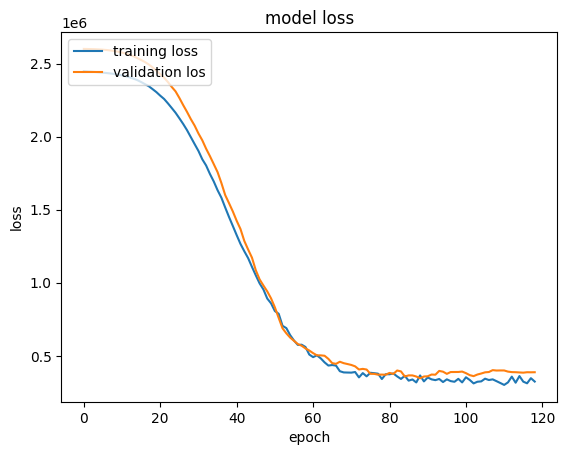

<module 'matplotlib.pyplot' from 'e:\\M2_s1\\all_environements\\ml_env1\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [71]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training loss', 'validation los'], loc='upper left')
plt.show()
plt

<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/3x3hj8VY/pngtree-colorful-pastel-gradient-background-texture-in-shades-of-pink-purple-blue-image-16381316.jpg);font-family:newtimeroman;font-size:120%;color:black;text-align:center;border-radius:15px 50px; padding:7px">III. ANN Evaluating</p>

<a class="btn" href="#home">📅 ANN Evaluating</a>

In [72]:
#Prediction
y_pred_train = model.predict(X_train)
y_pred_train

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[1558.9517  ],
       [1308.0969  ],
       [1613.8564  ],
       [1359.9855  ],
       [1319.8627  ],
       [1327.3993  ],
       [1427.7329  ],
       [1497.6257  ],
       [1563.8508  ],
       [1586.9778  ],
       [1429.8679  ],
       [1573.3794  ],
       [1257.3649  ],
       [1414.2612  ],
       [1459.4017  ],
       [1500.1696  ],
       [1464.7883  ],
       [1438.9275  ],
       [1411.816   ],
       [1574.6692  ],
       [1526.9988  ],
       [1458.8322  ],
       [1631.3984  ],
       [1501.7708  ],
       [1506.4854  ],
       [1310.5837  ],
       [ 988.62787 ],
       [1419.5945  ],
       [1312.5398  ],
       [1551.9822  ],
       [1332.6262  ],
       [1108.751   ],
       [1200.3807  ],
       [1525.305   ],
       [1330.0262  ],
       [1468.1257  ],
       [ 411.12854 ],
       [1442.0411  ],
       [1340.9506  ],
       [1452.9681  ],
       [ 638.31744 ],
       [1515.1624  ],
       [1496.7334  ],
       [1395.0743  ],
       [1301.6693  ],
       [11

In [73]:
y_pred_test = model.predict(X_test)
y_pred_test

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


array([[1406.809  ],
       [1353.0769 ],
       [1475.4158 ],
       [1384.1826 ],
       [1340.452  ],
       [1443.1001 ],
       [1168.909  ],
       [1469.6348 ],
       [1578.7861 ],
       [1364.1493 ],
       [1573.7966 ],
       [1343.4625 ],
       [1418.645  ],
       [1030.9875 ],
       [1242.7507 ],
       [1495.407  ],
       [1344.4246 ],
       [1214.3059 ],
       [1478.7831 ],
       [1454.0223 ],
       [1390.7803 ],
       [1564.8018 ],
       [1541.0349 ],
       [ 915.568  ],
       [1398.9048 ],
       [1474.7323 ],
       [1696.813  ],
       [ 901.63715],
       [1339.1895 ],
       [1285.5707 ],
       [1827.3596 ],
       [1541.5415 ],
       [1546.8472 ],
       [1393.7946 ],
       [1416.2975 ],
       [1312.8134 ],
       [1419.1223 ],
       [1304.639  ],
       [1484.2827 ],
       [1492.9583 ],
       [1477.7544 ],
       [1462.0834 ],
       [ 499.30954],
       [1582.3274 ],
       [1399.2539 ],
       [1387.7932 ],
       [1537.6693 ],
       [1573.

In [74]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
MSE = mean_squared_error(y_test, y_pred_test)
r2_score(y_train, y_pred_train)
RMSE = root_mean_squared_error(y_test, y_pred_test)

print(f"MSE: {MSE}")
print(f"R2 score: {r2_score(y_train, y_pred_train)}")
print(f"RMSE", RMSE)

MSE: 324034.49159822543
R2 score: -0.13414681558117314
RMSE 569.2402758047127
